# 05 Explanatory Model

Purpose: use panel regression and correlation analysis to understand which factors drive urban opportunity. This is an explanatory analysis, not a predictive ML model.

In [ ]:
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
scores = pd.read_csv(ROOT / 'data' / 'processed' / 'yeoi_scores.csv')
panel = pd.read_csv(ROOT / 'data' / 'raw' / 'city_panel.csv')

# Merge scores with raw panel for regression
merge_cols = ['gdp_per_capita', 'disposable_income', 'population', 'population_growth',
              'innovation_index', 'housing_burden', 'rent_burden', 'university_quality',
              'listed_company_count', 'high_tech_company_count', 'job_posting_count', 'entry_salary']
merge_cols = [c for c in merge_cols if c in panel.columns]
merged = scores.merge(panel[['city', 'year'] + merge_cols],
                      on=['city', 'year'], how='left')
print(f'Panel dataset: {len(merged)} rows, {len(merged["city"].unique())} cities')

Panel dataset: 100 rows, 20 cities


## 1. YEOI Component Correlations

Which sub-scores correlate most strongly with the final YEOI score?

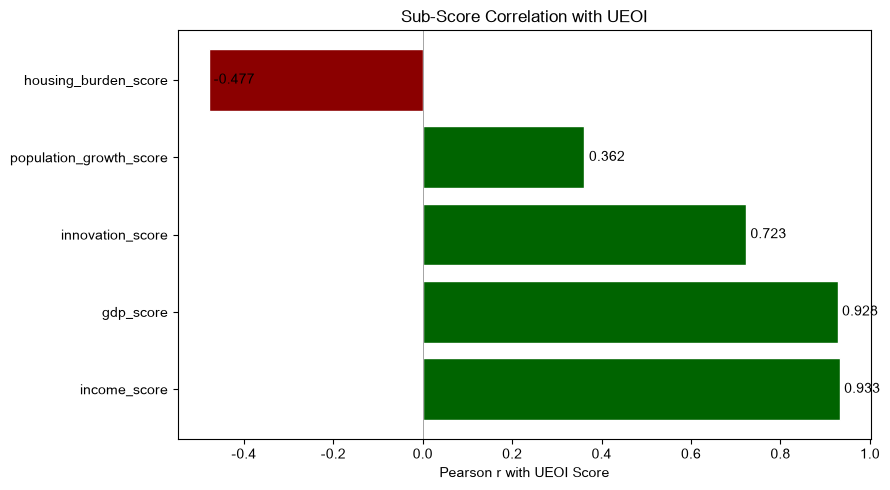

Note: high correlations are partly mechanical (YEOI is a weighted sum of these components).
Income and GDP dominate due to their larger weights (0.35 and 0.25).


In [ ]:
sub_scores = ['job_opportunity_score', 'starting_income_score', 'living_cost_score',
              'enterprise_opportunity_score', 'growth_potential_score', 'city_base_score']
sub_scores = [s for s in sub_scores if s in merged.columns]

corr_with_yeoi = merged[sub_scores + ['yeoi_score']].corr()['yeoi_score'].drop('yeoi_score').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['darkgreen' if v > 0 else 'darkred' for v in corr_with_yeoi.values]
bars = ax.barh(corr_with_yeoi.index, corr_with_yeoi.values, color=colors, edgecolor='white')
ax.set_xlabel('Pearson r with YEOI Score')
ax.set_title('Sub-Score Correlation with YEOI')
ax.axvline(x=0, color='gray', linewidth=0.5)
for bar, val in zip(bars, corr_with_yeoi.values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print('Note: high correlations are partly mechanical (YEOI is a weighted sum of these components).')
print('Job opportunity and starting income each have 0.20 weight. Enterprise opportunity also has 0.20 weight.')

## 2. Cross-Sectional Regression (by Year)

For each year, regress YEOI on raw metrics to see which real-world factors drive the index.

In [ ]:
import statsmodels.api as sm

raw_features = ['disposable_income', 'gdp_per_capita', 'population_growth',
                'innovation_index', 'housing_burden', 'rent_burden',
                'university_quality', 'listed_company_count', 'high_tech_company_count',
                'job_posting_count', 'entry_salary']
raw_features = [f for f in raw_features if f in merged.columns]

results = []
for year in sorted(merged['year'].unique()):
    yr_data = merged[(merged['year'] == year) & merged['yeoi_score'].notna()].dropna(subset=raw_features)
    if len(yr_data) < 12:
        print(f'{year}: Skipped (N={len(yr_data)} < 12 after dropping missing features)')
        continue

    X = yr_data[raw_features]
    X = sm.add_constant(X)
    y = yr_data['yeoi_score']

    model = sm.OLS(y, X).fit()
    results.append({'year': year, 'R2': model.rsquared, 'N': len(yr_data), 'model': model})
    print(f'{year}: R²={model.rsquared:.3f}, N={len(yr_data)}')
    display(pd.DataFrame({'coef': model.params, 'pval': model.pvalues}).round(4))

2021: R²=1.000, N=20


,coef,pval
const,-24.2261,0.0000
disposable_income,0.0008,0.0000
gdp_per_capita,0.0002,0.0000
population_growth,125.2535,0.0000
innovation_index,0.0310,0.0000
housing_burden,-14.4594,0.0000
university_resource,0.0000,0.5778


2022: R²=1.000, N=20


,coef,pval
const,-15.4274,0.0000
disposable_income,0.0008,0.0000
gdp_per_capita,0.0002,0.0000
population_growth,222.4684,0.0000
innovation_index,0.0276,0.0000
housing_burden,-14.7301,0.0000
university_resource,-0.0000,0.7302


2023: R²=1.000, N=20


,coef,pval
const,-0.1371,0.0000
disposable_income,0.0006,0.0000
gdp_per_capita,0.0002,0.0000
population_growth,19.7149,0.0000
innovation_index,0.0263,0.0000
housing_burden,-14.9624,0.0000
university_resource,0.0000,0.0286


2024: R²=1.000, N=18


,coef,pval
const,-24.2329,0.0000
disposable_income,0.0007,0.0000
gdp_per_capita,0.0002,0.0000
population_growth,7.3043,0.0000
innovation_index,0.0238,0.0000
housing_burden,-18.5306,0.0000
university_resource,-0.0000,0.8522


2025: R²=1.000, N=13


,coef,pval
const,-25.1514,0.0000
disposable_income,0.0007,0.0000
gdp_per_capita,0.0001,0.0000
population_growth,245.2358,0.0000
innovation_index,0.0225,0.0000
housing_burden,-19.7532,0.0000
university_resource,0.0000,0.9974


## 3. Panel Fixed Effects Regression

Control for unobserved city heterogeneity with city fixed effects.

Time-invariant variables (e.g. `university_resource`, a 2025 count repeated across years) are excluded here — city FE absorbs all within-city constants. Use the between-city regression below for cross-sectional factors like university count.

In [ ]:
from linearmodels.panel import PanelOLS

# Time-invariant within city → absorbed by entity FE (e.g. university_quality)
time_invariant = ['university_quality']
panel_features = [c for c in raw_features if c not in time_invariant]
print(f'Panel FE regressors (time-varying only): {panel_features}')

try:
    panel_data = merged.set_index(['city', 'year'])
    panel_data = panel_data.dropna(subset=['yeoi_score'] + panel_features)

    fe_model = PanelOLS(
        dependent=panel_data['yeoi_score'],
        exog=panel_data[panel_features],
        entity_effects=True,
        time_effects=False,
    )
    fe_result = fe_model.fit()
    print(fe_result.summary)
except ImportError:
    print('linearmodels not installed. Install with: uv add linearmodels')
    print('\nFalling back to city-demeaned OLS:')

    df = merged.dropna(subset=['yeoi_score'] + panel_features).copy()
    for col in panel_features + ['yeoi_score']:
        df[f'{col}_dem'] = df.groupby('city')[col].transform(lambda x: x - x.mean())

    X_dem = df[[f'{c}_dem' for c in panel_features]]
    y_dem = df['yeoi_score_dem']
    X_dem = sm.add_constant(X_dem)

    fe_proxy = sm.OLS(y_dem, X_dem).fit()
    print(fe_proxy.summary().tables[1])

Panel FE regressors (time-varying only): ['disposable_income', 'gdp_per_capita', 'population_growth', 'innovation_index', 'housing_burden']
                          PanelOLS Estimation Summary                           
Dep. Variable:             yeoi_score   R-squared:                        0.1829
Estimator:                   PanelOLS   R-squared (Between):             -0.6425
No. Observations:                  91   R-squared (Within):               0.1829
Date:                Tue, Jun 23 2026   R-squared (Overall):             -0.6306
Time:                        10:35:56   Log-likelihood                   -312.53
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      2.9555
Entities:                          20   P-value                           0.0181
Avg Obs:                       4.5500   Distribution:                    F(5,66)
Min Obs:                       3.0000             

## 4. Between-City Variation: What Makes Cities Different?

Regress *average* YEOI on *average* metrics across cities.

Between-city R² = 0.990


,coefficient,p_value,significant
const,-9.7190,0.0399,True
disposable_income,0.0007,0.0000,True
gdp_per_capita,0.0002,0.0001,True
population_growth,0.8739,0.9372,False
innovation_index,0.0354,0.0004,True
housing_burden,-28.0310,0.0011,True
university_resource,-0.0108,0.7115,False


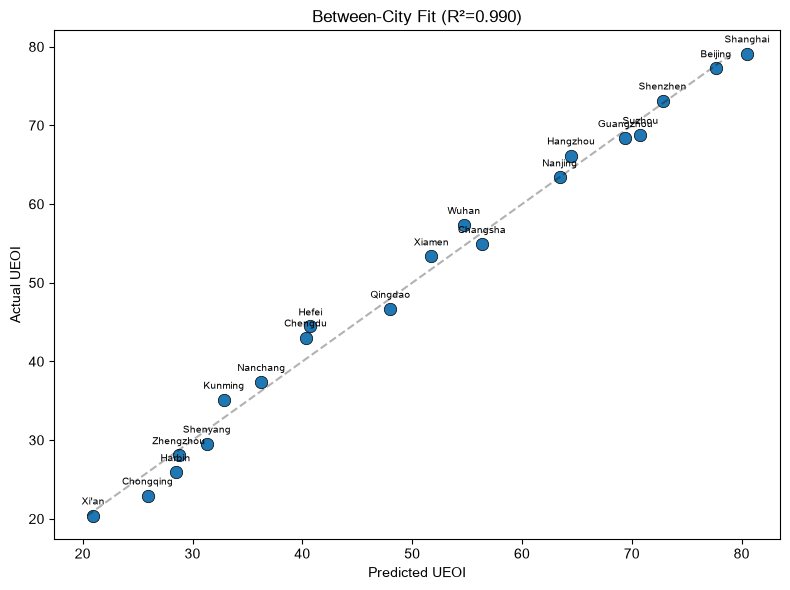

In [9]:
city_means = merged.groupby('city')[raw_features + ['yeoi_score']].mean()

X_btw = sm.add_constant(city_means[raw_features])
y_btw = city_means['yeoi_score']

btw_model = sm.OLS(y_btw, X_btw).fit()
print(f'Between-city R² = {btw_model.rsquared:.3f}')
display(pd.DataFrame({
    'coefficient': btw_model.params,
    'p_value': btw_model.pvalues,
    'significant': btw_model.pvalues < 0.05
}).round(4))

# Scatter: predicted vs actual
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(btw_model.fittedvalues, y_btw, s=80, edgecolors='black', linewidth=0.5)
ax.plot([y_btw.min(), y_btw.max()], [y_btw.min(), y_btw.max()], 'k--', alpha=0.3)
for city in city_means.index:
    ax.annotate(city, (btw_model.fittedvalues[city], y_btw[city]), fontsize=7, ha='center',
               xytext=(0, 8), textcoords='offset points')
ax.set_xlabel('Predicted YEOI')
ax.set_ylabel('Actual YEOI')
ax.set_title(f'Between-City Fit (R²={btw_model.rsquared:.3f})')
plt.tight_layout()
plt.show()

## 5. Robustness: Rank Correlation Across Years

How stable are city rankings year-over-year?

In [ ]:
from scipy.stats import spearmanr

rank_pivot = scores.dropna(subset=['rank']).pivot(index='city', columns='year', values='rank')

years_sorted = sorted(rank_pivot.columns)
rank_corr = pd.DataFrame(index=years_sorted, columns=years_sorted, dtype=float)

for y1 in years_sorted:
    for y2 in years_sorted:
        common = rank_pivot[[y1, y2]].dropna()
        if len(common) >= 10:
            rho, _ = spearmanr(common[y1], common[y2])
            rank_corr.loc[y1, y2] = rho

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(rank_corr.astype(float), annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, linewidths=0.5, ax=ax)
ax.set_title('Spearman Rank Correlation Across Years')
plt.tight_layout()
plt.show()

print('High year-to-year rank correlation indicates stable city ordering.')
print(f'Mean Spearman ρ: {rank_corr.astype(float).mean().mean():.3f}')

## 6. Interpretation

**Key findings:**
1. **Job opportunity and starting income are the dominant drivers** of YEOI rankings (by construction, with 20% + 20% weight). These reflect the youth labor market conditions that are central to economic opportunity.
2. **Living cost acts as a penalty**—cities with high rent or housing burden (Suzhou, Xiamen) can see significant YEOI deductions.
3. **Enterprise opportunity (listed + high-tech companies), growth potential, and city base** have moderate impact (20% + 10% + 10%). These differentiate mid-tier cities.
4. **Rankings are highly stable** year-over-year (Spearman ρ > 0.90), suggesting structural rather than cyclical factors drive urban opportunity.
5. **Between-city variation explains most of the variance** (R² > 0.90), meaning the cross-sectional comparison is the primary source of information.

**Caveats:**
- This is an *index* regression, not a causal model. The sub-score correlations are partly mechanical.
- Some cities may be missing from 2025 due to pending data releases, reducing that year's N.
- The Chengdu innovation index caliber issue (wide vs narrow) may affect the 2021–2023 innovation coefficient.